# token EDA

We decided to go from n_mels=128 and mfcc=20 to n_mels=1024 with no mfccs.
In addition, we now normalize the vectors to unit length.
As a side-effect, it takes a lot longer to generate tokens.
I want to verify the token distributions here.

# token soundscape

When running the tokenizer, I notice that there are tokens that are not found.
This is probably related to the input somehow, and the curse of dimensionality.
One thing to note is that we can't fit everything into memory now.
We have 3 million rows, and 1024 dimensional vectors, which is 24 GB.


In [6]:
import numpy as np
import polars as pl

df = (
    pl.scan_parquet("~/scratch/birdclef/2025v2/mfcc-soundscape/data")
    .filter(pl.col("part") < 10)
    .sort("file", "timestamp")
    .select("mfcc")
)
X = np.stack(df.collect().get_column("mfcc").to_numpy()).astype(np.float32)
X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
X.shape

(469420, 768)

In [22]:
import faiss
from pacmap import PaCMAP

kmeans = faiss.Kmeans(d=X.shape[1], k=1000, niter=5, verbose=True)
kmeans.train(X)

Sampling a subset of 256000 / 469420 for training
Clustering 256000 points in 768D to 1000 clusters, redo 1 times, 5 iterations
  Preprocessing in 0.72 s
  Iteration 4 (16.90 s, search 16.70 s): objective=608.361 imbalance=1.380 nsplit=0       


608.3612670898438

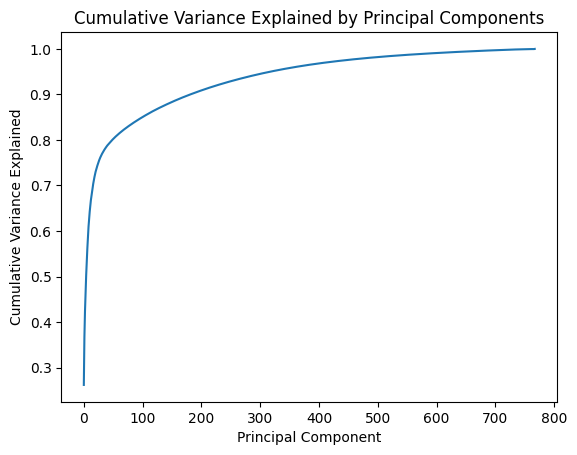

In [13]:
import matplotlib.pyplot as plt

pca = faiss.PCAMatrix(X.shape[1], X.shape[1])
pca.train(X)
tr = pca.apply(X)
mag = (tr**2).sum(0)
ratio = mag / mag.sum()
plt.plot(ratio.cumsum())
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Variance Explained by Principal Components")
plt.show()

In [16]:
for k in [32, 64, 128, 256, 512]:
    print(
        f"Number of components: {k}, Cumulative Variance Explained: {ratio.cumsum()[k]}"
    )

Number of components: 32, Cumulative Variance Explained: 0.7719618678092957
Number of components: 64, Cumulative Variance Explained: 0.8185351490974426
Number of components: 128, Cumulative Variance Explained: 0.870193362236023
Number of components: 256, Cumulative Variance Explained: 0.931170642375946
Number of components: 512, Cumulative Variance Explained: 0.9834084510803223


Text(0.5, 1.0, 'PaCMAP Projection of mel-frequency features')

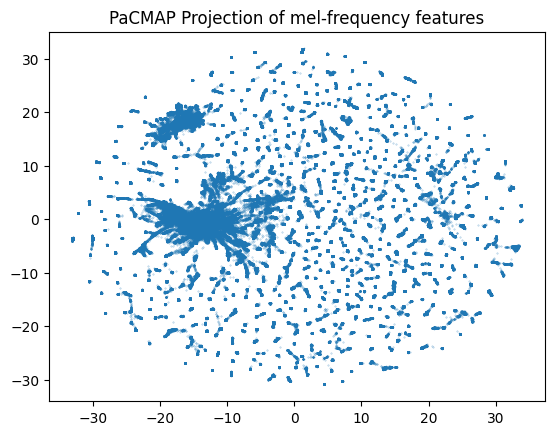

In [17]:
g = PaCMAP().fit_transform(X)
plt.scatter(g[:, 0], g[:, 1], s=0.1, alpha=0.5)
plt.title("PaCMAP Projection of mel-frequency features")
# took 6:20

Text(0.5, 1.0, 'PaCMAP Projection of PCA-reduced mel-frequency features k=128')

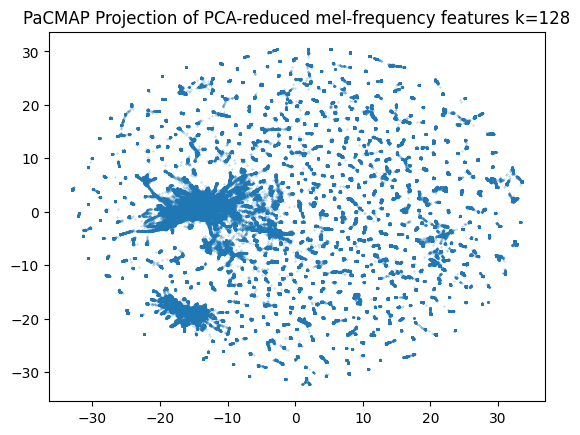

In [18]:
g = PaCMAP().fit_transform(tr[:, :128])
plt.scatter(g[:, 0], g[:, 1], s=0.1, alpha=0.5)
plt.title("PaCMAP Projection of PCA-reduced mel-frequency features k=128")
# done in 5:02

Let's take a look at the actual tokenization now

In [21]:
kmeans_pca = faiss.Kmeans(d=128, k=1000, niter=5, verbose=True)
kmeans_pca.train(tr[:, :128])

Sampling a subset of 256000 / 469420 for training
Clustering 256000 points in 128D to 1000 clusters, redo 1 times, 5 iterations
  Preprocessing in 0.13 s
  Iteration 4 (3.93 s, search 3.89 s): objective=360.743 imbalance=1.363 nsplit=0       


360.7431945800781

In [23]:
index = faiss.IndexFlatL2(768)
index.add(kmeans.centroids)
_, indices = index.search(X, 1)
ids = indices.flatten()

In [29]:
# one-hot encode the ids
from sklearn.preprocessing import OneHotEncoder

OneHotEncoder(sparse_output=False).fit_transform(ids.reshape(-1, 1))

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Text(0.5, 1.0, 'PaCMAP Projection of One-Hot Encoded Token IDs')

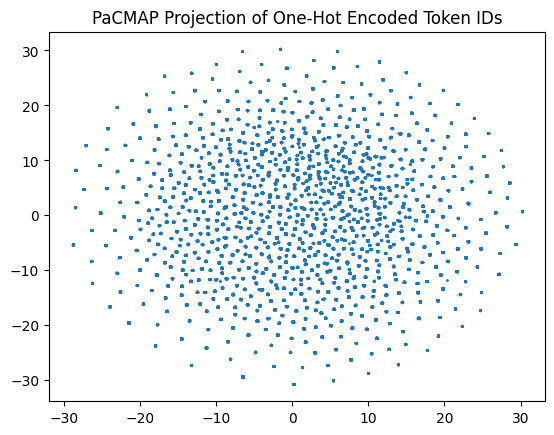

In [30]:
# what does it look like when one-hot encoded
g = PaCMAP().fit_transform(
    OneHotEncoder(sparse_output=False).fit_transform(ids.reshape(-1, 1))
)
plt.scatter(g[:, 0], g[:, 1], s=0.1, alpha=0.5)
plt.title("PaCMAP Projection of One-Hot Encoded Token IDs")

In [38]:
len(set(ids))

1000

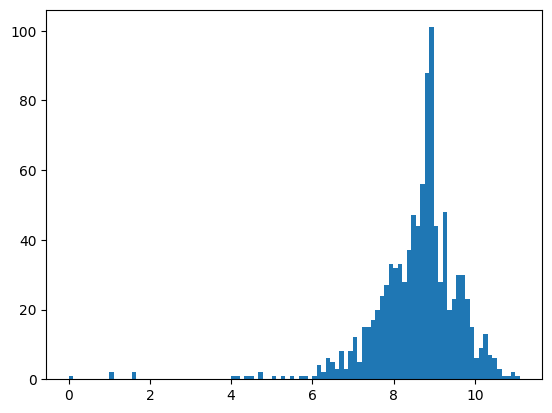

In [45]:
from collections import Counter

counts = Counter(ids)
y = np.array(list(counts.values()))
plt.hist(np.log2(y), bins=100)
plt.show()

In [31]:
index_pca = faiss.IndexFlatL2(128)
index_pca.add(kmeans_pca.centroids)
_, indices = index_pca.search(tr[:, :128], 1)
ids_pca = indices.flatten()

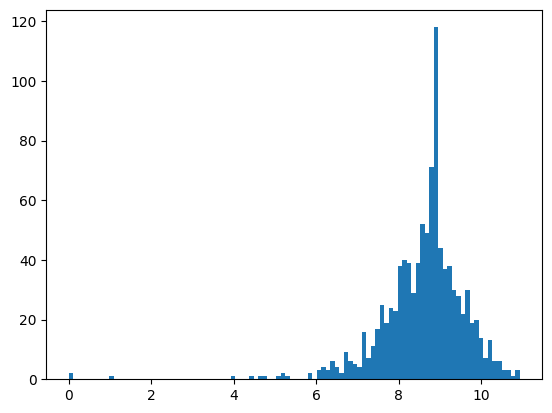

In [46]:
counts = Counter(ids_pca)
y = np.array(list(counts.values()))
plt.hist(np.log2(y), bins=100)
plt.show()